In [1]:
import pandas as pd

df = pd.read_csv("../data/preprocessed/train.csv")
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Female,Male,Age Group,Interaction Frequency,Churn
0,-1.317667,-1.222065,0.651239,0.921373,0.394475,-0.895356,0.895356,-1.722856,1.003122,0.0
1,-1.633098,-0.903046,1.479306,-1.922014,-0.534765,-0.895356,0.895356,-1.722856,-0.218334,1.0
2,0.022917,-0.265009,0.651239,-1.444976,-0.650920,-0.895356,0.895356,0.668872,-0.218334,1.0
3,0.338349,-0.584028,1.597601,0.170168,0.162165,1.116875,-1.116875,0.668872,1.003122,1.0
4,0.732638,1.649101,-0.531715,0.965503,-0.767075,-0.895356,0.895356,0.668872,-0.218334,1.0


In [2]:
df.shape

(404165, 10)

In [3]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.1, random_state=24)

In [5]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
from sklearn.metrics import classification_report

yhat = xgb.predict(X_test)
print("Classification Report")
print(classification_report(y_test, yhat))

Classification Report
              precision    recall  f1-score   support

         0.0       0.96      0.87      0.91     17933
         1.0       0.90      0.97      0.94     22484

    accuracy                           0.93     40417
   macro avg       0.93      0.92      0.92     40417
weighted avg       0.93      0.93      0.93     40417



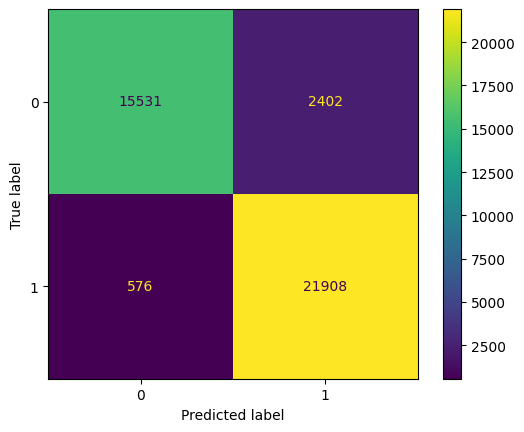

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

cm = confusion_matrix(y_test, yhat, labels=xgb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb.classes_)
disp.plot()
plt.show()

In [8]:
import os
import time
import pickle

os.makedirs("../models", exist_ok=True)

timestamp = time.time()
file_name = f"../models/xgb_{timestamp}.pkl"
pickle.dump(xgb, open(file_name, "wb"))